<a href="https://colab.research.google.com/github/mannan234-cmd/InternCircle-Data-Science-AI/blob/main/InternCircle_Task_04_First_Machine_Learning_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InternCircle — Task 04

## First Machine Learning Classifier

### Decision Tree Classifier using Scikit-Learn

**Name:** Muhammad Mannan Masud

**Internship:** InternCircle — Data Science & AI

### Project Overview

This project demonstrates a basic **supervised machine learning workflow** using the **Iris dataset** and a **Decision Tree Classifier** from Scikit-Learn. The model is trained to classify Iris flowers into different species based on their flower measurements.

### Objectives

The main objectives of this task are to load and explore the Iris dataset, prepare the data for machine learning, split the dataset into training and testing sets, train a Decision Tree Classification model using Scikit-Learn, make predictions on unseen test data, and evaluate the model using **Accuracy** and a **Confusion Matrix**.

### Machine Learning Workflow

The project follows the basic supervised machine learning pipeline: **Dataset → Data Exploration → Train/Test Split → Model Training → Prediction → Evaluation**.

### Tools & Technologies

* Python
* Google Colab
* Scikit-Learn
* Pandas
* Matplotlib
* Seaborn

### Dataset

The project uses the **Iris dataset**, a commonly used dataset for learning classification algorithms. It contains measurements of Iris flowers and their corresponding species.

### Model Used

**Decision Tree Classifier** — a supervised machine learning algorithm that makes predictions by learning a series of decision rules from the training data.

### Evaluation

The trained model is evaluated using **Accuracy**, which measures the percentage of correct predictions, and a **Confusion Matrix**, which shows how many samples were correctly and incorrectly classified for each class.

### Expected Outcome

By completing this task, I will understand the fundamental workflow of a supervised machine learning classification problem, from loading and exploring data to training, predicting, and evaluating a machine learning model.


In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
# Load the Iris dataset

iris = load_iris()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display basic information about the dataset

print("Feature Names:")
print(iris.feature_names)

print("\nTarget Names:")
print(iris.target_names)

print("\nDataset Shape:")
print(iris.data.shape)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
(150, 4)


In [4]:
# Convert the dataset into a Pandas DataFrame

df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["target"] = iris.target

# Add the actual flower species name
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [8]:
# Check dataset information
# Separate features (X) and target (y)

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Features shape: (150, 4)
Target shape: (150,)
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


In [9]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [10]:
# Create the Decision Tree Classifier

model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [11]:
# Train the Decision Tree model

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
# Make predictions using the testing data

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [13]:
# Compare actual values with predicted values

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Actual Species"] = comparison["Actual"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

comparison["Predicted Species"] = comparison["Predicted"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

comparison

,Actual,Predicted,Actual Species,Predicted Species
0,0,0,setosa,setosa
1,2,2,virginica,virginica
2,1,1,versicolor,versicolor
3,1,1,versicolor,versicolor
4,0,0,setosa,setosa
5,1,1,versicolor,versicolor
6,0,0,setosa,setosa
7,0,0,setosa,setosa
8,2,2,virginica,virginica
9,1,1,versicolor,versicolor


In [14]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 93.33%


In [15]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


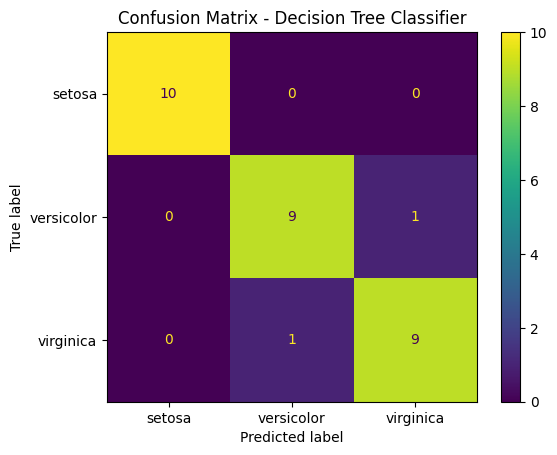

In [16]:
# Display the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.show()

In [17]:
# Display classification report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



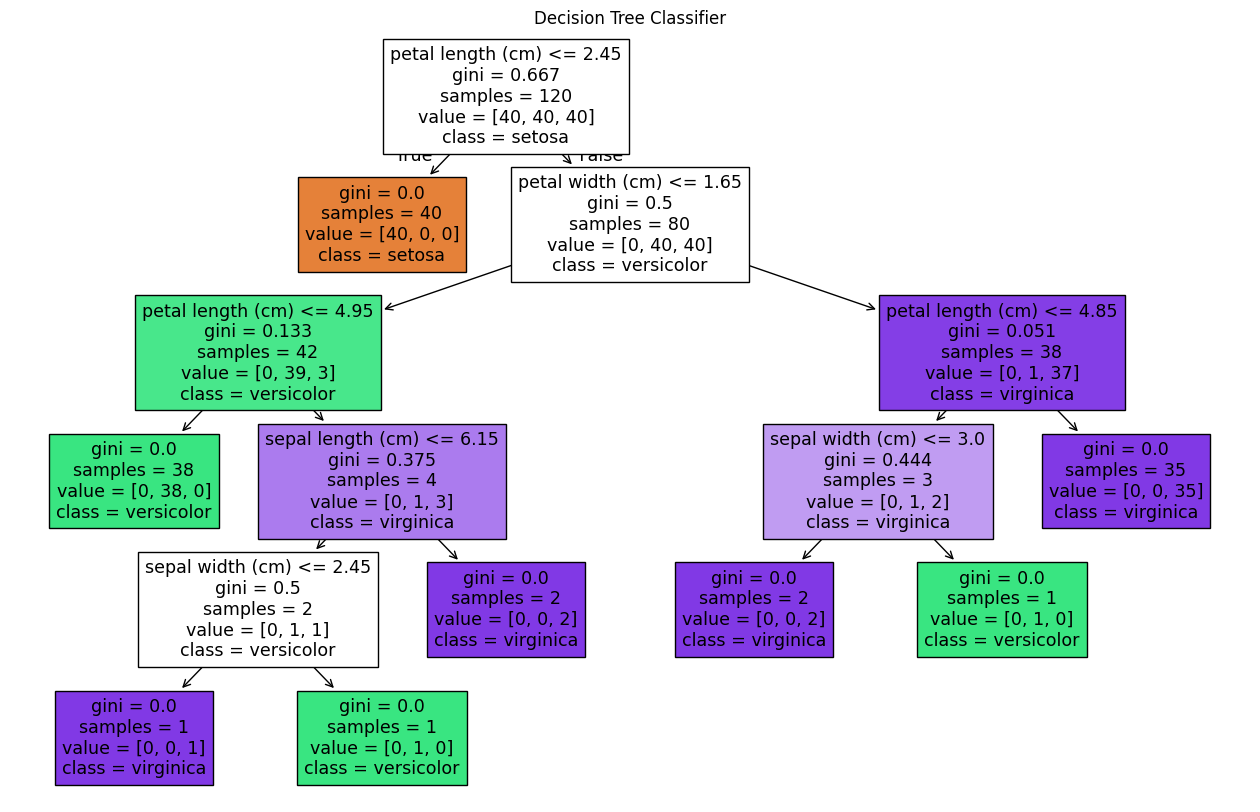

In [18]:
# Visualize the trained Decision Tree

from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree Classifier")
plt.show()

In [19]:
# Display feature importance

feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,petal length (cm),0.558568
3,petal width (cm),0.406015
1,sepal width (cm),0.029167
0,sepal length (cm),0.006250


In [20]:
# Final model evaluation

print("========== FINAL MODEL EVALUATION ==========")
print(f"Model: Decision Tree Classifier")
print(f"Training Samples: {len(X_train)}")
print(f"Testing Samples: {len(X_test)}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print("============================================")

========== FINAL MODEL EVALUATION ==========
Model: Decision Tree Classifier
Training Samples: 120
Testing Samples: 30
Accuracy: 93.33%


# Conclusion

In this project, we successfully built a **Decision Tree Classifier** using **Scikit-Learn** and the **Iris dataset**. The dataset was first loaded and explored to understand its features, structure, and target classes. It was then divided into **training and testing sets using an 80/20 split**.

The Decision Tree model was trained using the training data and then used to predict the classes of the unseen testing data. The model's performance was evaluated using **Accuracy** and a **Confusion Matrix**. Accuracy showed the percentage of test samples classified correctly, while the confusion matrix provided a detailed view of the correct and incorrect predictions for each Iris flower class.

Overall, this project provided practical experience with the fundamental **supervised machine learning pipeline**, including data loading, data exploration, data preparation, train-test splitting, model training, prediction, and performance evaluation. It also helped develop a basic understanding of how a Decision Tree Classifier can be applied to a real classification problem.
